# 动态分支
含义是，节点运行过程中，根据状态，决定后面跳转到那里去， 有点像前面的条件判断，不能创建新的节点，只是运行的过程中，
1. 触发哪些
2. 触发几次


两个典型用法
1. send 根据当前状态可以触发哪些任务 （用的多一点，因为不太方便用静态方式实现，专门属于动态分支）
2. command 跳转到下游节点（用静态分支也可以实现）

send的场景：
1. s -> a -> b -> end , 一般a和b只能执行一次，但是send可以根据不同的状态，让a以不同的内容运行n次，叫send


如何操作： 要结合`add_conditional_edges`使用，动态扇出任务，扇出“上游像扇子一样，往下游发出多个任务，例如
1. 一个主题，同时生成三个任务
2. 根据list，给list每个元素动态启动该任务

启动任务的个数可以是不确定的，可以运行的过程中， 由于列表元素的个数决定，所以称为动态，动态的实现需要Send的实例，有两个参数，
1. 第一个参数是node节点，
2. 第二个是arg：给下游额外的参数 （每个Send实例接收到的arg是独立的，互不相关）

{'poem': '## 《猫咪》\n\n你凝望窗外时，\n把白昼，\n蜷成毛线团。\n\n玻璃印着不动声色的\n狩猎者。而你只是\n踱步，将爪印\n铺成明暗的密文。\n\n午睡的谵妄里，\n我听见你追赶\n自己的尾巴，把光线\n纺成线轴。再松开\n千百个晨昏。\n\n银匙搅动夜幕，\n牛奶涨潮的港口，\n你俯身饮下。霎时\n弧形的深渊随呼吸\n起伏。', 'ci_poem': '好的，这里为你生成几组不同风格的关于猫咪的中文词，包括常用叠词、雅称、成语以及一组意象诗词汇总：\n\n**一、 常用可爱叠词（适合日常与撒娇）**\n*   **喵喵**：拟声，最直接的猫咪呼唤。\n*   **咪咪**：对猫咪的通用昵称。\n*   **绒绒**：形容猫毛柔软蓬松。\n*   **肉肉**：特指猫咪粉嫩的爪垫（肉球）。\n*   **奶乖**：形容幼猫或性格温顺的猫，奶声奶气。\n\n**二、 古典雅称（适合文赋、国风创作）**\n*   **衔蝉**：古代对猫的雅称，因其捕鼠如衔蝉，也指纯白猫。\n*   **狸奴**：古人对猫的爱称，意为“捕鼠的奴仆”，黄庭坚有诗“聘得狸奴”。\n*   **玉面**：指白脸猫咪。\n*   **乌圆**：指毛色黑而油亮的猫。\n*   **雪球**：指全身雪白的长毛猫。\n\n**三、 成语与典故（适合描写猫的状态或性格）**\n*   **睡猫扑蝶**：形容动静结合的生命趣味（非标准成语，常被文人引用）。\n*   **虎视眈眈**：借用猫盯猎物时的眼神，形容专注。\n*   **伸爪亮甲**：形容猫咪伸懒腰或防卫时的状态。\n*   **猫鼠同眠**：虽为贬义（比喻失职），也可用来揶揄自家猫和仓鼠和平共处。\n*   **招财纳福**：特指“招财猫”的吉庆含义。\n\n**四、 唯美意象词汇（适合文案与摄影）**\n*   **琥珀凝光**：形容猫咪在暗处发亮的金色眼眸。\n*   **踏雪寻梅**：形容黑猫白爪，走在雪地里的意象（或指白猫踩梅花印）。\n*   **肉垫无声**：指猫咪走路悄无声息，自带优雅。\n*   **午后团绒**：形容猫咪在阳光下缩成一团睡觉的样子。\n*   **眉间川字**：特指某些猫（如波斯猫）傲娇皱眉的神态。\n\n**五、 趣味动词与状态词**\n*   **踩奶**：猫咪用前爪反复按压柔软

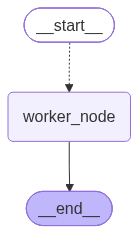

In [11]:
# 动态分支
from typing import TypedDict, Literal
from collections.abc import Sequence

from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

load_dotenv(override=True)
CONTENT_TYPES = ["poem", "ci_poem", "joke"]


model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body= {
        "thinking": {
            "type": "disabled"
        }
    }
)

# 定义状态
# 1.1 全局状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str

# 1.2 私有状态  ，内部自己使用
class WorkerState(TypedDict):
    content_type: Literal["poem", "ci_poem", "joke"]
    prompt: str

# 1.3 输入状态
class InputState(TypedDict):
    topic: str

# 1.4 输出状态
class OutputState(TypedDict, total = False): # 加了total后，都变成可选，除非指定
    poem: str
    ci_poem: str
    joke: str

# 2. 定义节点 ， 让动态分支执行的任务节点
# 作用，让类型写诗，就写诗，写笑话写笑话
def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]

    content = model.invoke([HumanMessage(content=prompt)]).content
    return { # 不标准的返回参数
        content_type: content #  类似于 ： {"poem": "诗句"}
    }


def router(state: InputState) -> Sequence[Send]: # Send的
    router_prompt = "请生成关于{} 的 {}"
    english2Chinese = {
        "poem": "诗",
        "joke": "笑话",
        "ci_poem": "中文词",
    }
    topic = state["topic"]

    sends: list[Send] = []
    for content_type in CONTENT_TYPES: # 动态分配代码
        worker_state: WorkerState = { # 这个类型实际上是WorkerState，传递给worker_node节点的
            "content_type": content_type,
            "prompt": router_prompt.format(topic,  english2Chinese[content_type]) # 字符串替换
        }
        sends.append(Send("worker_node", worker_state)) # 注意Send第一个参数为字符串

    return sends # 一个节点，执行了三次

    # return [
    #     Send(
    #         "worker_node",
    #         {
    #             "content_type": content_type,
    #             "prompt": router_prompt.format(topic, english2Chinese[content_type])
    #         }
    #     ) for content_type in CONTENT_TYPES
    # ]


#4. 构建图
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)

builder.add_node("worker_node", worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map={
        "worker_node": "worker_node"
    }
)
builder.add_edge("worker_node", END)

graph = builder.compile()

result = graph.invoke({"topic": "猫咪"})
print(result)

display(graph) # 虚线表示条件运行

# 可以看到执行的效果， 实现给下游扇出多个任务，看起来只有虚线一个节点，但是有三次不同的任务
# 使用send实现的

### 直接回答

在 `TypedDict` 中，**所有字段默认都是必选的（Required）**，不是可选的。

```python
class OutputState(TypedDict):
    poem: str      # ✅ 必选
    ci_poem: str   # ✅ 必选
    joke: str      # ✅ 必选
```

但这里有一个**关键区分**：`TypedDict` 的"必选/可选"是**类型检查层面**的概念，不是运行时强制校验。

---

### TypedDict vs 普通类 vs Pydantic 对比

| 特性 | `TypedDict` | 普通 `class` | `Pydantic BaseModel` |
| :--- | :--- | :--- | :--- |
| 默认是否必选 | ✅ 是 | ❌ 无此概念 | ✅ 是 |
| 运行时强制校验 | ❌ **不会** | ❌ 不会 | ✅ **会报错** |
| 缺失字段时 | 静默通过，IDE/type checker 警告 | 取决于 `__init__` | 抛出 `ValidationError` |
| 适用场景 | 类型注解、LangGraph State | 通用 OOP | 数据验证、API |

> ⚠️ **重要提醒**：`TypedDict` 本质是 `dict` 的类型注解增强，**运行时不做任何校验**。以下代码不会报错：
> ```python
> state: OutputState = {"poem": "xxx"}  # 缺少 ci_poem 和 joke
> # 运行时完全正常！只有 mypy/pyright 等静态检查器会提示
> ```

---

### 如何显式控制必选/可选

#### 1. TypedDict 中标记可选字段
```python
from typing_extensions import TypedDict, NotRequired, Required

class OutputState(TypedDict):
    poem: str              # 必选（默认）
    ci_poem: NotRequired[str]  # ✅ 可选
    joke: Required[str]        # 显式标记必选（用于 total=False 时）
```

或者用 `total=False` 反转默认行为：
```python
class OutputState(TypedDict, total=False):
    poem: str              # 变成可选
    ci_poem: Required[str] # 显式必选
    joke: str              # 可选
```

#### 2. 如果需要运行时强制校验 → 用 Pydantic
```python
from pydantic import BaseModel, Field

class OutputState(BaseModel):
    poem: str                          # 必选，缺失即报错
    ci_poem: str                       # 必选
    joke: str = Field(default="")      # 有默认值 → 可选
```

---

### 📌 针对你的 LangGraph 场景的建议

LangGraph 的 `StateGraph` 使用 `TypedDict` 定义状态时：

-   **类型层面**：所有字段必选，IDE 会在你返回不完整 dict 时给出提示
-   **运行层面**：LangGraph 内部用 reducer 合并状态，节点只需返回**部分更新**，不需要返回全部字段
    ```python
    def node_a(state: OutputState) -> dict:
        return {"poem": "一首诗"}  # ✅ 合法！只更新 poem，其他字段保持不变
    ```
-   如果你希望某个字段在初始调用时可以不提供，用 `NotRequired`：
    ```python
    class OverAllState(MessagesState):
        username: str                    # 必选，invoke 时必须传
        output: NotRequired[str]         # 可选，可由节点后续填充
    ```

> 💡 **总结**：`TypedDict` 字段默认必选但仅作用于静态类型检查；需要运行时校验请用 Pydantic；在 LangGraph 中节点返回值天然支持部分更新，无需担心"必选"导致必须返回所有字段。